# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

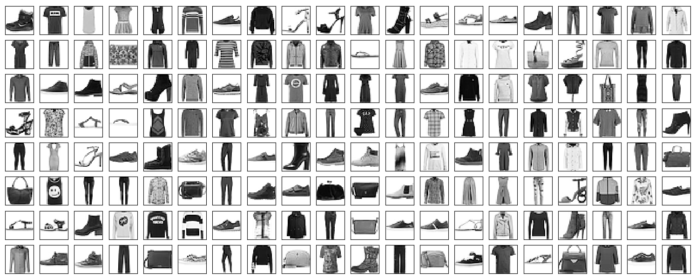


## 데이터 로드

In [1]:
import tensorflow as tf

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 데이터 shape 확인

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [6]:
import matplotlib.pyplot as plt

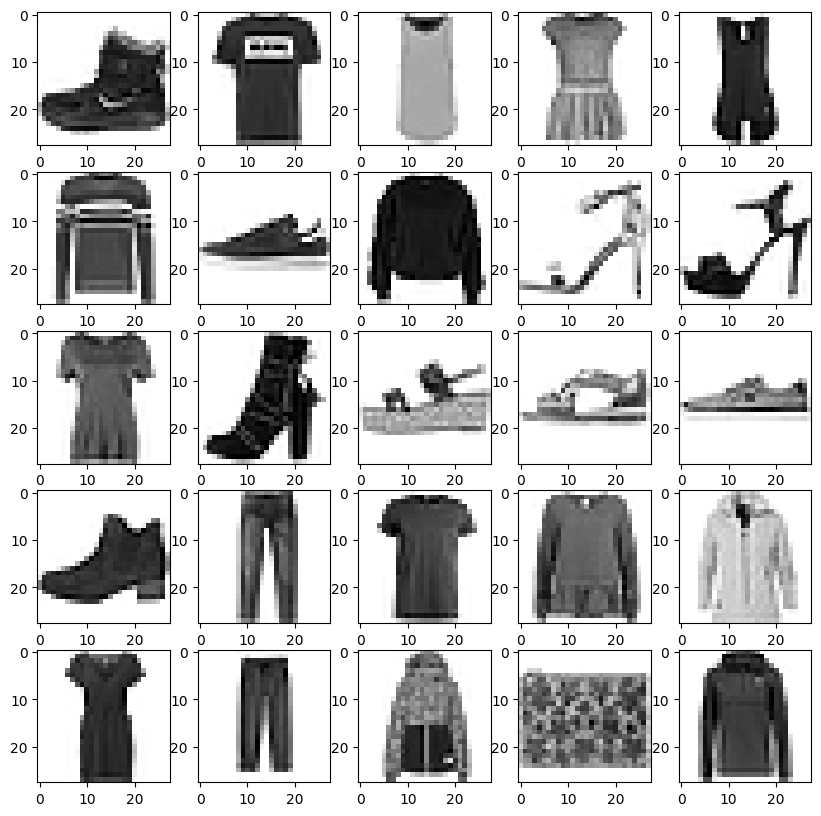

In [7]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [8]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

In [9]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [10]:
print([items[i] for i in y_train[:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


In [11]:
import numpy as np

In [12]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [13]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [14]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [18]:
from sklearn.model_selection import train_test_split

In [21]:
x_train1, x_val, y_train1, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [22]:
print(x_train.shape, y_train.shape)   #원 train 데이타
print(x_train1.shape, y_train1.shape) #검증데이타 제외 데이타
print(x_val.shape, y_val.shape)       #검증 데이타
print(x_test.shape, y_test.shape)     #테스트 데이타

(60000, 28, 28) (60000,)
(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


## one-hot encoding

In [23]:
y_train = tf.keras.utils.to_categorical(y_train1, num_classes=10) #trainning 데이타
y_val = tf.keras.utils.to_categorical(y_val, num_classes=10)      #검증데이타
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)    #테스트데이타

In [24]:
print(y_train.shape, y_val.shape, y_test.shape)

(48000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [25]:
x_train = x_train1 / 255
x_val = x_val / 255
x_test = x_test / 255

In [26]:
print(x_val[:10])

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.00784314 0.         0.43921569 ... 0.         0.         0.00392157]
  [0.00784314 0.         0.08235294 ... 0.         0.00392157 0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.      

## 직렬화

In [27]:
x_train = x_train.reshape(-1, 28*28)
x_val = x_val.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [28]:
print(x_train.shape, x_val.shape, x_test.shape)

(48000, 784) (12000, 784) (10000, 784)


## model 생성

In [29]:
from tensorflow.keras import layers, models

In [30]:
model = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss='categorical_crossentropy', metrics=['acc'])

## 학습

In [33]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - acc: 0.7862 - loss: 0.5910 - val_acc: 0.8279 - val_loss: 0.4617
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8469 - loss: 0.4185 - val_acc: 0.8537 - val_loss: 0.3901
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8617 - loss: 0.3765 - val_acc: 0.8661 - val_loss: 0.3614
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8720 - loss: 0.3501 - val_acc: 0.8617 - val_loss: 0.3787
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8789 - loss: 0.3310 - val_acc: 0.8706 - val_loss: 0.3623
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8847 - loss: 0.3150 - val_acc: 0.8752 - val_loss: 0.3446
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8867 - loss: 0.3055 - val_acc: 0.8743 - val_loss: 0.3617
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8914 - loss: 0.2947 - val_acc: 0.8757 - val_loss: 0.3508
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━

In [34]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8737 - loss: 0.5239


[0.5239449143409729, 0.8737000226974487]

In [35]:
print(x_test.shape)
print(x_test[0].shape)
print(x_test[:1].shape)

(10000, 784)
(784,)
(1, 784)


## 학습곡선

In [37]:
history.history

{'acc': [0.7862083315849304,
  0.8469374775886536,
  0.8617291450500488,
  0.871958315372467,
  0.8789166808128357,
  0.8847083449363708,
  0.8866666555404663,
  0.8914374709129333,
  0.8942708373069763,
  0.898812472820282,
  0.8989375233650208,
  0.9018750190734863,
  0.9050416946411133,
  0.9068750143051147,
  0.9070208072662354,
  0.9097499847412109,
  0.9107083082199097,
  0.9133750200271606,
  0.9135416746139526,
  0.9157708287239075,
  0.9178958535194397,
  0.9167291522026062,
  0.917229175567627,
  0.9184166789054871,
  0.9196041822433472,
  0.9208333492279053,
  0.9238541722297668,
  0.9229583144187927,
  0.9254791736602783,
  0.9250208139419556],
 'loss': [0.590990424156189,
  0.41853076219558716,
  0.3765134811401367,
  0.3501174747943878,
  0.33097460865974426,
  0.31496661901474,
  0.3055173456668854,
  0.29473045468330383,
  0.28634485602378845,
  0.2771850526332855,
  0.27186402678489685,
  0.26639240980148315,
  0.2615908980369568,
  0.2577415406703949,
  0.251718610525

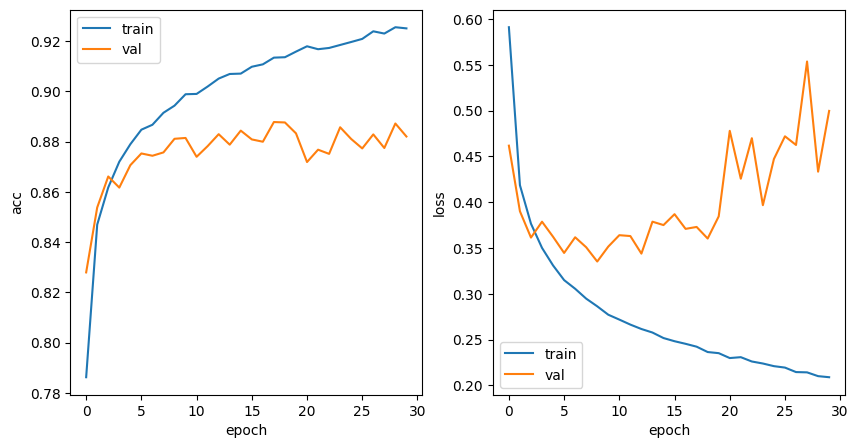

In [38]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train','val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

## 과대적합(Over fitting)/과소적합(Under fitting)

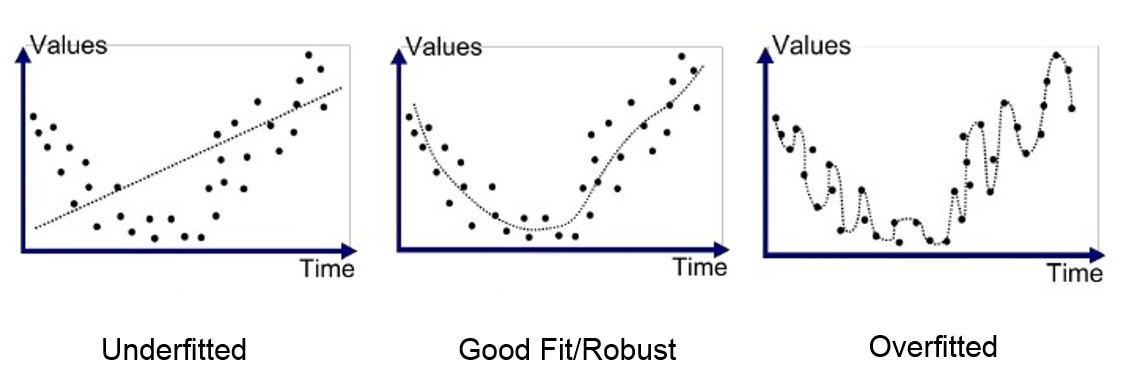

In [50]:
#Overfitting 막기위해 Drop-out 적용
model1 = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [51]:
model1.compile(loss='categorical_crossentropy', metrics=['acc'])

In [52]:
history1 = model1.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - acc: 0.7686 - loss: 0.6381 - val_acc: 0.8315 - val_loss: 0.4554
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8349 - loss: 0.4561 - val_acc: 0.8512 - val_loss: 0.4095
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8487 - loss: 0.4191 - val_acc: 0.8597 - val_loss: 0.3855
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8554 - loss: 0.3968 - val_acc: 0.8650 - val_loss: 0.3690
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8604 - loss: 0.3800 - val_acc: 0.8726 - val_loss: 0.3514
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8663 - loss: 0.3703 - val_acc: 0.8757 - val_loss: 0.3501
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8711 - loss: 0.3592 - val_acc: 0.8753 - val_loss: 0.3449
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.8731 - loss: 0.3544 - val_acc: 0.8742 - val_loss: 0.3454
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━

In [53]:
history1.history

{'acc': [0.768583357334137,
  0.8349375128746033,
  0.8486666679382324,
  0.8554166555404663,
  0.8603749871253967,
  0.8663333058357239,
  0.8711041808128357,
  0.8731250166893005,
  0.8752708435058594,
  0.8769791722297668,
  0.878291666507721,
  0.8804166913032532,
  0.8793749809265137,
  0.8814166784286499,
  0.8819791674613953,
  0.8818541765213013,
  0.882645845413208,
  0.8843125104904175,
  0.8849375247955322,
  0.8849166631698608,
  0.8862083554267883,
  0.8878958225250244,
  0.8886874914169312,
  0.8862291574478149,
  0.8886666893959045,
  0.8894374966621399,
  0.8925416469573975,
  0.8898749947547913,
  0.8898958563804626,
  0.8917708396911621],
 'loss': [0.6381474733352661,
  0.4560883343219757,
  0.4190948009490967,
  0.39684799313545227,
  0.3799925446510315,
  0.37030935287475586,
  0.3591540455818176,
  0.354417085647583,
  0.348550945520401,
  0.34581729769706726,
  0.3427884578704834,
  0.33945417404174805,
  0.33841535449028015,
  0.3368108570575714,
  0.337814688682

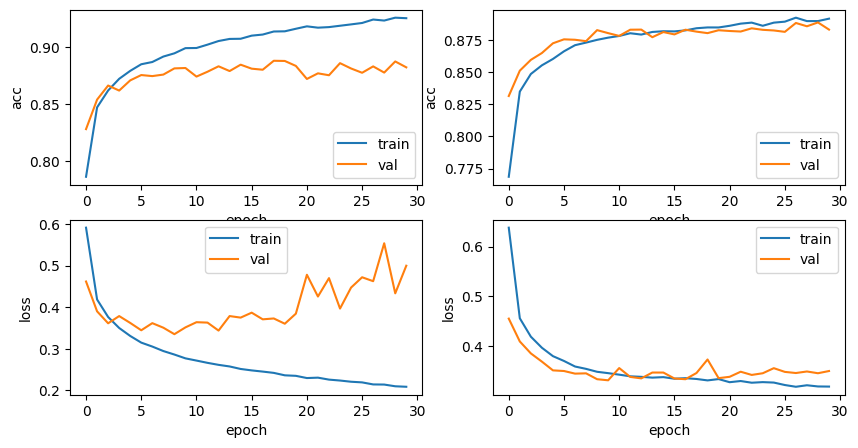

In [54]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train','val'])
plt.xlabel('epoch')
plt.ylabel('acc')
plt.subplot(2,2,2)
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.legend(['train','val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(2,2,3)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.subplot(2,2,4)
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['train','val'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

In [46]:
model.evaluate(x_test, y_test)
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8737 - loss: 0.5239
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8798 - loss: 0.3595


[0.35951748490333557, 0.879800021648407]

In [47]:
model.save('fmnist_nn.keras')

In [48]:
model3 = models.load_model('fmnist_nn.keras')

In [49]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,294 (868.34 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 111,148 (434.18 KB)